In [1]:
import pandas as pd
df=pd.read_csv("/content/Sentiment Analysis for Mental Health.csv")

In [2]:
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


##data information or EDA



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27639 entries, 0 to 27638
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  27639 non-null  int64 
 1   statement   27629 non-null  object
 2   status      27639 non-null  object
dtypes: int64(1), object(2)
memory usage: 647.9+ KB


In [4]:
df.shape

(27639, 3)

In [5]:
df['status'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress'],
      dtype=object)

In [6]:
df.columns

Index(['Unnamed: 0', 'statement', 'status'], dtype='object')

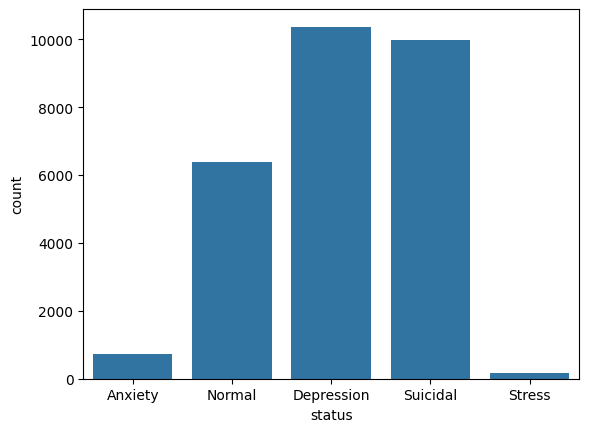

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='status',data=df)
plt.show()

In [8]:
df['status'].value_counts()

,count
status,
Depression,10371
Suicidal,9993
Normal,6383
Anxiety,733
Stress,159


In [9]:
df=df.drop(['Unnamed: 0'],axis=1)
df.head(5)

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [10]:
df.sample(10)

,statement,status
4314,Ohhh Dreamies there will be content on MelonxS...,Normal
17430,the worst part is i cannot even tell if I am f...,Depression
20108,"Therapy, medication, exercise.therapy, medicat...",Depression
7063,I do not know what happened. Over the course o...,Depression
17687,I just want to end it all but i feel so guilty...,Suicidal
1188,sablay again,Normal
17348,I have done everything. I do skincare twice a ...,Depression
16429,I am 22 about to turn 23 in a few months.I had...,Depression
1979,ni-ki brilliant,Normal
19431,"If nothing gets better by Saturday, I have to ...",Suicidal


In [11]:
df.duplicated().sum()

np.int64(100)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.isnull().sum()

,0
statement,2
status,0


In [15]:
df=df.dropna()

##text preprocessing

In [16]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('stopwords')
ps=PorterStemmer()



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
def clean_text(text):
  text=re.sub('[^a-zA-Z]',' ',text)
  text=text.lower()
  text=text.split()
  text=[ps.stem(word) for word in text if not word in stopwords.words('english')]
  text=' '.join(text)
  return text

In [18]:
df['statement']=df['statement'].apply(clean_text)

In [19]:
df['status'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress'],
      dtype=object)

In [20]:
new_data = df.copy()

In [21]:
new_data['status'] = ['Depression' if x == 'Suicidal' else x for x in new_data['status']]
new_data['status'] = ['Stress' if x == 'Anxiety' else x for x in new_data['status']]

In [22]:
new_data['status'].unique()

array(['Stress', 'Normal', 'Depression'], dtype=object)

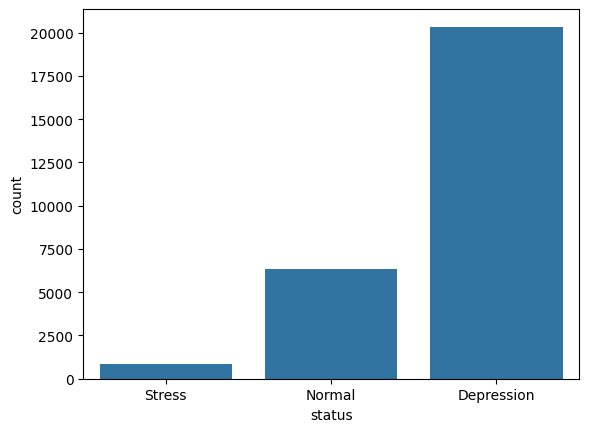

In [23]:
sns.countplot(x='status',data=new_data)
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    new_data['statement'],
    new_data['status'],
    test_size=0.2,
    random_state=42,
    stratify=new_data['status'],
    shuffle=True
    )

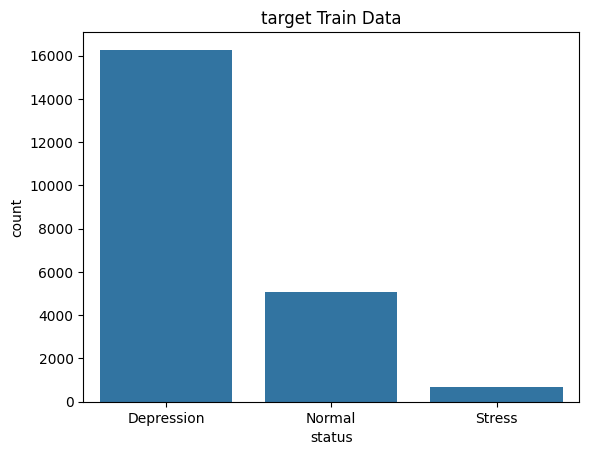

In [25]:
sns.countplot(x=y_train,data=new_data)
plt.title('target Train Data')
plt.show()

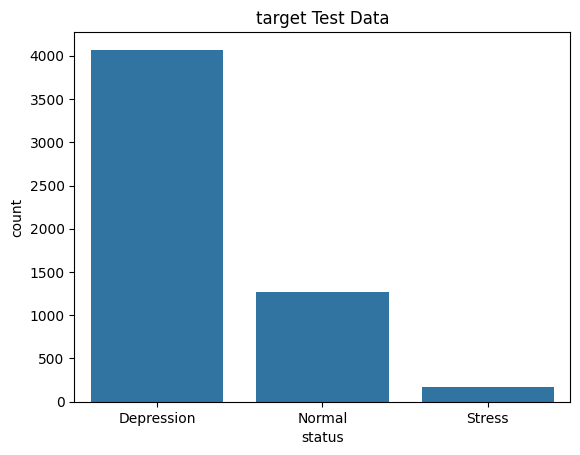

In [26]:
sns.countplot(x=y_test,data=new_data)
plt.title('target Test Data')
plt.show()

In [27]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()


In [28]:
y_train=le.fit_transform(y_train)

In [32]:
y_train

array([0, 1, 0, ..., 0, 0, 0])

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf=TfidfVectorizer()


In [30]:
x_train = tf.fit_transform(x_train).toarray()

In [31]:
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [34]:
y_test=le.transform(y_test)
x_test=tf.transform(x_test).toarray()

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

rf=RandomForestClassifier()
nb=MultinomialNB()
xgb=XGBClassifier()

In [36]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

rf.fit(x_train, y_train, sample_weight=sample_weights)
nb.fit(x_train, y_train, sample_weight=sample_weights)
xgb.fit(x_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [37]:
models = {'Random Forest': rf, 'Naive Bayes': nb, 'XGBoost': xgb}

for name, model in models.items():
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*40}")
    print(f"{name} — Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


Random Forest — Accuracy: 0.9493
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      4070
           1       0.91      0.91      0.91      1264
           2       0.96      0.61      0.75       174

    accuracy                           0.95      5508
   macro avg       0.94      0.83      0.88      5508
weighted avg       0.95      0.95      0.95      5508


Naive Bayes — Accuracy: 0.8862
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      4070
           1       0.98      0.56      0.71      1264
           2       0.45      0.75      0.56       174

    accuracy                           0.89      5508
   macro avg       0.77      0.77      0.74      5508
weighted avg       0.90      0.89      0.88      5508


XGBoost — Accuracy: 0.9443
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      4070
           1       0.86      0.96  

In [38]:
import joblib

joblib.dump(rf, 'Mental_Health.pkl')
joblib.dump(tf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']